# Income and Language

## Important Column Names
- `S1902_C03_001E` the mean household income (E: estimate) for all households in that GEO_ID / Census Tract
- `S1902_C02_001M` the margin of error (M: Margin of error) for mean income for all households in that GEO_ID / Census Tract
- `S1902_C01_001E` number of households in that GEO_ID / Census Tract
- `S1903_C03_001E` the median household income (E: Estimate) for all households in that GEO_ID
- `S1903_C03_001M` the margin of error (M: Margin of error) for median income for all


In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob


from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib
from pathlib import Path

import random

# local mods
import geo_utils as geo
import clean_utils as clean

In [4]:
# Import the intersection text data
path = "data/raw/test2026-06-13/*.xlsx"
files = glob.glob(path)

# Load each file into a list of DataFrames
df_list = [pd.read_excel(file) for file in files]

# Combine them into one master DataFrame and drop na
master_df = pd.concat(df_list, ignore_index=True)
master_df = master_df.dropna(subset=["intersection","text_on_sign_exact"])
# clean the strings so they have punctuation removed and such
master_df = clean.clean_string_columns(master_df,columns=["text_on_sign_exact"])
# import additional data for mapping coordinates to intersection names
coordinates = pd.read_csv("data/raw/coordinate_dict/coordinate_dict2026-06-19.csv")
platte_river_points = pd.read_csv("data/raw/platte_points.csv")
# drop na and transition latitude and longitude strings
# to a float format
coordinates[["latitude", "longitude"]] = (
    coordinates["cd"]
    .dropna()
    .apply(geo.parse_dms_coordinate)
    .apply(pd.Series)
)
# merge the coordinate sheet with the master sheet
# so the data can be trained
training_data_raw = master_df.merge(
    coordinates[["intersection", "latitude", "longitude", "zip", "city"]],
    on="intersection",
    how="left"
)
training_data_raw.to_csv("training_data_raw.csv")

# create a dataframe that has one row per instersection with
# all of the text combined for that intersection
intersection_df = (
    training_data_raw
    .groupby("intersection")
    .agg({
        "text_on_sign_exact": " ".join,
        "latitude": "first",
        "longitude": "first",
        "zip": "first",
        "city": "first"
    })
    .reset_index()
    .rename(columns={"text_on_sign_exact": "text_blob"})
)
intersection_df.head()

,intersection,text_blob,latitude,longitude,zip,city
0,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora


In [5]:
intersection_points = gpd.GeoDataFrame(
    intersection_df,
    geometry=gpd.points_from_xy(
        intersection_df["longitude"], 
        intersection_df["latitude"]
    ),
    crs="EPSG:4326"
)

In [6]:
intersection_points.head()

,intersection,text_blob,latitude,longitude,zip,city,geometry
0,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,POINT (-105.00017 39.73372)
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,POINT (-104.99869 39.73367)
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,POINT (-104.89881 39.73292)
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,POINT (-104.88475 39.73286)
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,POINT (-104.86583 39.73647)


In [7]:
intersection_points_meters =intersection_points.to_crs(epsg=32613)
intersection_points_meters.head()

,intersection,text_blob,latitude,longitude,zip,city,geometry
0,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,POINT (499985.718 4398203.671)
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,POINT (500111.874 4398197.506)
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,POINT (508671.488 4398119.161)
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,POINT (509875.935 4398114.449)
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,POINT (511496.332 4398517.484)


In [8]:
intersection_points_meters["buffer_100m"] = intersection_points_meters.geometry.buffer(100)
buffers = intersection_points_meters.set_geometry("buffer_100m")
buffers.head()

,intersection,text_blob,latitude,longitude,zip,city,geometry,buffer_100m
0,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,POINT (499985.718 4398203.671),"POLYGON ((500085.718 4398203.671, 500085.237 4..."
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,POINT (500111.874 4398197.506),"POLYGON ((500211.874 4398197.506, 500211.392 4..."
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,POINT (508671.488 4398119.161),"POLYGON ((508771.488 4398119.161, 508771.006 4..."
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,POINT (509875.935 4398114.449),"POLYGON ((509975.935 4398114.449, 509975.454 4..."
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,POINT (511496.332 4398517.484),"POLYGON ((511596.332 4398517.484, 511595.85 43..."


In [9]:
block_medians = pd.read_csv("income_data/income_median_b1903.csv")
# get rid of descriptive row
block_medians = block_medians[block_medians["GEO_ID"] != "Geography"]
block_medians.head()

,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
1,1500000US080010078011,Block Group 1; Census Tract 78.01; Adams Count...,45576,21273,NaN
2,1500000US080010078012,Block Group 2; Census Tract 78.01; Adams Count...,71129,28687,NaN
3,1500000US080010078021,Block Group 1; Census Tract 78.02; Adams Count...,54109,7779,NaN
4,1500000US080010078022,Block Group 2; Census Tract 78.02; Adams Count...,-,**,NaN
5,1500000US080010078023,Block Group 3; Census Tract 78.02; Adams Count...,48906,23526,NaN


In [10]:
# open geopandas json
geo_data = gpd.read_file("income_data/Colorado_Census_Block_Group_Boundaries.geojson")

In [11]:
geo_data["GEO_ID"] = geo_data["AFFGEOID"]
geo_data.head()

,OBJECTID,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,AFFGEOID,geometry,GEO_ID
0,1,08,109,977700,3,081099777003,1500000US081099777003,"POLYGON ((-106.11235 37.75551, -106.11234 37.7...",1500000US081099777003
1,2,08,109,977600,3,081099776003,1500000US081099776003,"POLYGON ((-105.90777 37.99263, -105.9069 37.98...",1500000US081099776003
2,3,08,109,977600,1,081099776001,1500000US081099776001,"POLYGON ((-106.16087 38.06789, -106.16088 38.0...",1500000US081099776001
3,4,08,109,977700,2,081099777002,1500000US081099777002,"POLYGON ((-106.14907 37.75186, -106.14906 37.7...",1500000US081099777002
4,5,08,077,001502,4,080770015024,1500000US080770015024,"POLYGON ((-109.05148 39.11707, -109.05149 39.1...",1500000US080770015024


In [12]:
merged_geo_income_data = geo_data.merge(
    block_medians,
    on="GEO_ID",
    how="left"
)
merged_geo_income_data.head()

,OBJECTID,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,AFFGEOID,geometry,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,1,08,109,977700,3,081099777003,1500000US081099777003,"POLYGON ((-106.11235 37.75551, -106.11234 37.7...",1500000US081099777003,Block Group 3; Census Tract 9777; Saguache Cou...,57570,37191,NaN
1,2,08,109,977600,3,081099776003,1500000US081099776003,"POLYGON ((-105.90777 37.99263, -105.9069 37.98...",1500000US081099776003,Block Group 3; Census Tract 9776; Saguache Cou...,45156,17496,NaN
2,3,08,109,977600,1,081099776001,1500000US081099776001,"POLYGON ((-106.16087 38.06789, -106.16088 38.0...",1500000US081099776001,Block Group 1; Census Tract 9776; Saguache Cou...,50125,27685,NaN
3,4,08,109,977700,2,081099777002,1500000US081099777002,"POLYGON ((-106.14907 37.75186, -106.14906 37.7...",1500000US081099777002,Block Group 2; Census Tract 9777; Saguache Cou...,36083,20957,NaN
4,5,08,077,001502,4,080770015024,1500000US080770015024,"POLYGON ((-109.05148 39.11707, -109.05149 39.1...",1500000US080770015024,Block Group 4; Census Tract 15.02; Mesa County...,163424,32983,NaN


In [13]:
merged_geo_income_meters = merged_geo_income_data.to_crs(epsg=32613)
merged_geo_income_meters.head()

,OBJECTID,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,AFFGEOID,geometry,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,1,08,109,977700,3,081099777003,1500000US081099777003,"POLYGON ((402014.08 4179270.902, 402014.156 41...",1500000US081099777003,Block Group 3; Census Tract 9777; Saguache Cou...,57570,37191,NaN
1,2,08,109,977600,3,081099776003,1500000US081099776003,"POLYGON ((420291.501 4205385.687, 420359.08 42...",1500000US081099776003,Block Group 3; Census Tract 9776; Saguache Cou...,45156,17496,NaN
2,3,08,109,977600,1,081099776001,1500000US081099776001,"POLYGON ((398170.955 4213983.617, 398169.898 4...",1500000US081099776001,Block Group 1; Census Tract 9776; Saguache Cou...,50125,27685,NaN
3,4,08,109,977700,2,081099777002,1500000US081099777002,"POLYGON ((398773.748 4178905.799, 398773.555 4...",1500000US081099777002,Block Group 2; Census Tract 9777; Saguache Cou...,36083,20957,NaN
4,5,08,077,001502,4,080770015024,1500000US080770015024,"POLYGON ((149693.706 4337589.478, 149690.495 4...",1500000US080770015024,Block Group 4; Census Tract 15.02; Mesa County...,163424,32983,NaN


Text(0.5, 1.0, '100m Buffers around Intersections with Census Block Groups')

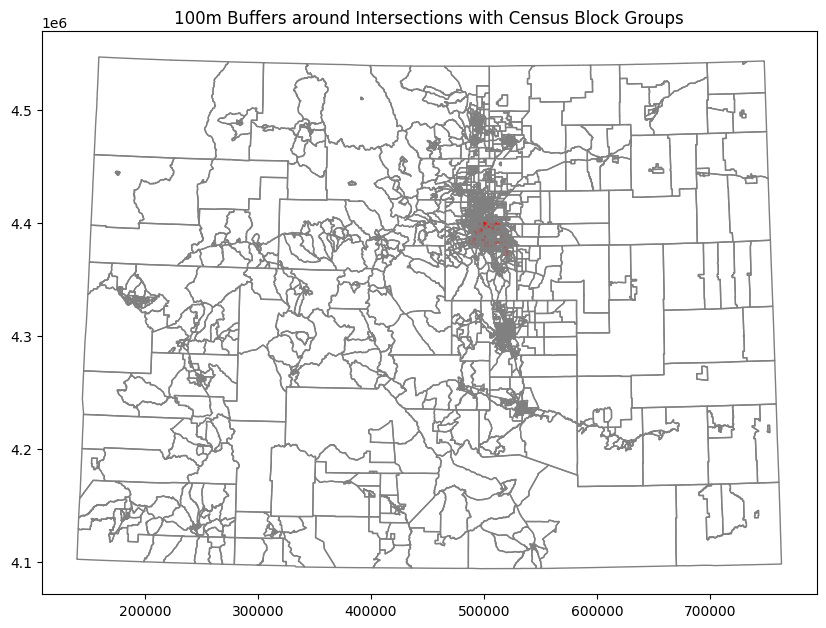

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
# plot the actual block group boundaries
merged_geo_income_meters.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray"
)
# plot the buffers around each intersection point
buffers.plot(
    ax=ax,
    alpha=0.5,
    edgecolor="red",
    facecolor="none"
)
plt.title("100m Buffers around Intersections with Census Block Groups")

In [24]:
overlap_results = gpd.overlay(
    buffers,
    merged_geo_income_meters,
    how="intersection"
)
overlap_results["overlap_area"] = overlap_results.geometry.area
overlap_results.head()

,intersection,text_blob,latitude,longitude,zip,city,geometry,OBJECTID,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,AFFGEOID,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4,overlap_area
0,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,"POLYGON ((500085.524 4398199.723, 500011.387 4...",2070,08,031,001800,1,080310018001,1500000US080310018001,1500000US080310018001,Block Group 1; Census Tract 18; Denver County;...,-,**,NaN,8183.340410
1,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,"POLYGON ((500085.237 4398193.869, 500083.797 4...",2071,08,031,001800,2,080310018002,1500000US080310018002,1500000US080310018002,Block Group 2; Census Tract 18; Denver County;...,101680,53635,NaN,7501.962643
2,11th-kalamath,anthem church required properties schielter an...,39.733722,-105.000167,80204.0,denver,"POLYGON ((499975.917 4398104.152, 499966.209 4...",2073,08,031,001901,2,080310019012,1500000US080310019012,1500000US080310019012,Block Group 2; Census Tract 19.01; Denver Coun...,122546,33650,NaN,15680.181852
3,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,"POLYGON ((500012.355 4398207.307, 500013.795 4...",2070,08,031,001800,1,080310018001,1500000US080310018001,1500000US080310018001,Block Group 1; Census Tract 18; Denver County;...,-,**,NaN,7793.868121
4,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,"POLYGON ((500211.392 4398187.704, 500209.952 4...",2071,08,031,001800,2,080310018002,1500000US080310018002,1500000US080310018002,Block Group 2; Census Tract 18; Denver County;...,101680,53635,NaN,16111.914379


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

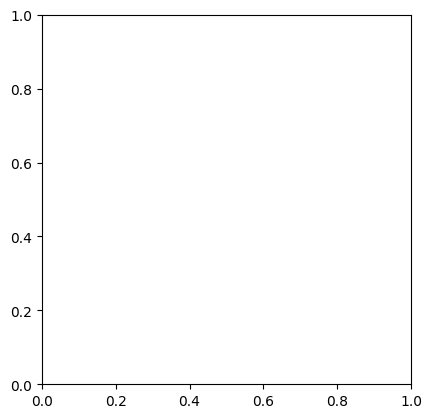

In [ ]:
overlap_results.plot(colu)

In [30]:
# focus in on the counties of interest at this point, but we could expand to all counties in the future
counties = ["DENVER", "ARAPAHOE", "DOUGLAS", "JEFFERSON", "ADAMS"]
# select a few key counties from the income data
denver_metro = income_data[income_data['County'].isin(counties)]

In [31]:
# 2015 to 2019 data
# denver_metro

<Axes: >

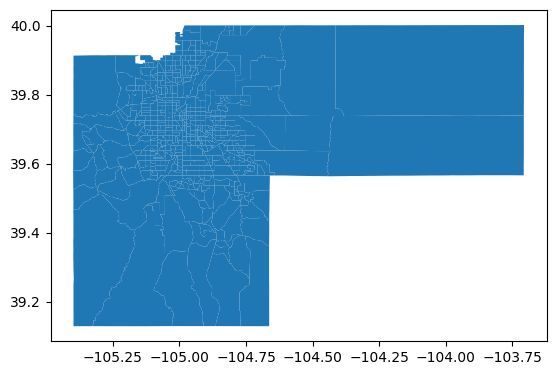

In [32]:
denver_metro.plot()

In [52]:
denver_metro.columns

Index(['OBJECTID', 'FIPS', 'County', 'Tract_Name', 'Population_Total',
       'Percent_Poverty_AllPeople_Income_Below_Pov_Level',
       'Poverty_Per_Capita_Income', 'Housing_Poverty_Median_Household_Income',
       'Housing_Poverty_Mean_Household_Income', 'geometry'],
      dtype='str')

## Next, we import the language data

In [49]:
# export missing coordinates to ensure that we can go back and manually add them in if needed
missing_coords = intersection_df[intersection_df["latitude"].isna()]
if not missing_coords.empty:
    missing_coords.to_csv("missing_coords.csv")
else:
    print("No missing coordinates to export.")

No missing coordinates to export.


## Logic for Census Data
if the intersecton is completely within the perimeter of one section, use the income of that section (Census Tract?)
if the intersecton is split across two intersections, leverage both sections 
if the intersecton is split across three instersections, leverage the three sections
if the intersecton is split across four intersections, leverage all four sections